#### ЦК-МЛ-91 Хоробрых Егор | 5 вариант | ReLu & Adagrad

In [1]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Загрузка датасета Iris
data = load_iris()
X = data.data
y = data.target

df = pd.DataFrame(data=data.data, columns=data.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
!pip list

Package                 Version
----------------------- ---------
anaconda-anon-usage     0.4.4
archspec                0.2.3
asttokens               2.4.1
beautifulsoup4          4.12.3
boltons                 23.0.0
Brotli                  1.0.9
certifi                 2024.8.30
cffi                    1.17.1
charset-normalizer      3.3.2
colorama                0.4.6
comm                    0.2.2
conda                   24.9.2
conda-content-trust     0.2.0
conda-libmamba-solver   24.9.0
conda-package-handling  2.3.0
conda_package_streaming 0.10.0
cryptography            43.0.0
debugpy                 1.8.5
decorator               5.1.1
distro                  1.9.0
emoji                   2.14.0
executing               2.1.0
frozendict              2.4.2
gh-md-to-html           1.21.3
idna                    3.7
ipykernel               6.29.5
ipython                 8.27.0
jedi                    0.19.1
jsonpatch               1.33
jsonpointer             2.1
libmambapy             

In [2]:
tf.__version__

'2.18.0'

In [3]:
print('The full description of the dataset:\n',data['DESCR'])

The full description of the dataset:
 .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribu

In [2]:
data['data'] #просто просмотр формата данных

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

<Figure size 500x300 with 0 Axes>

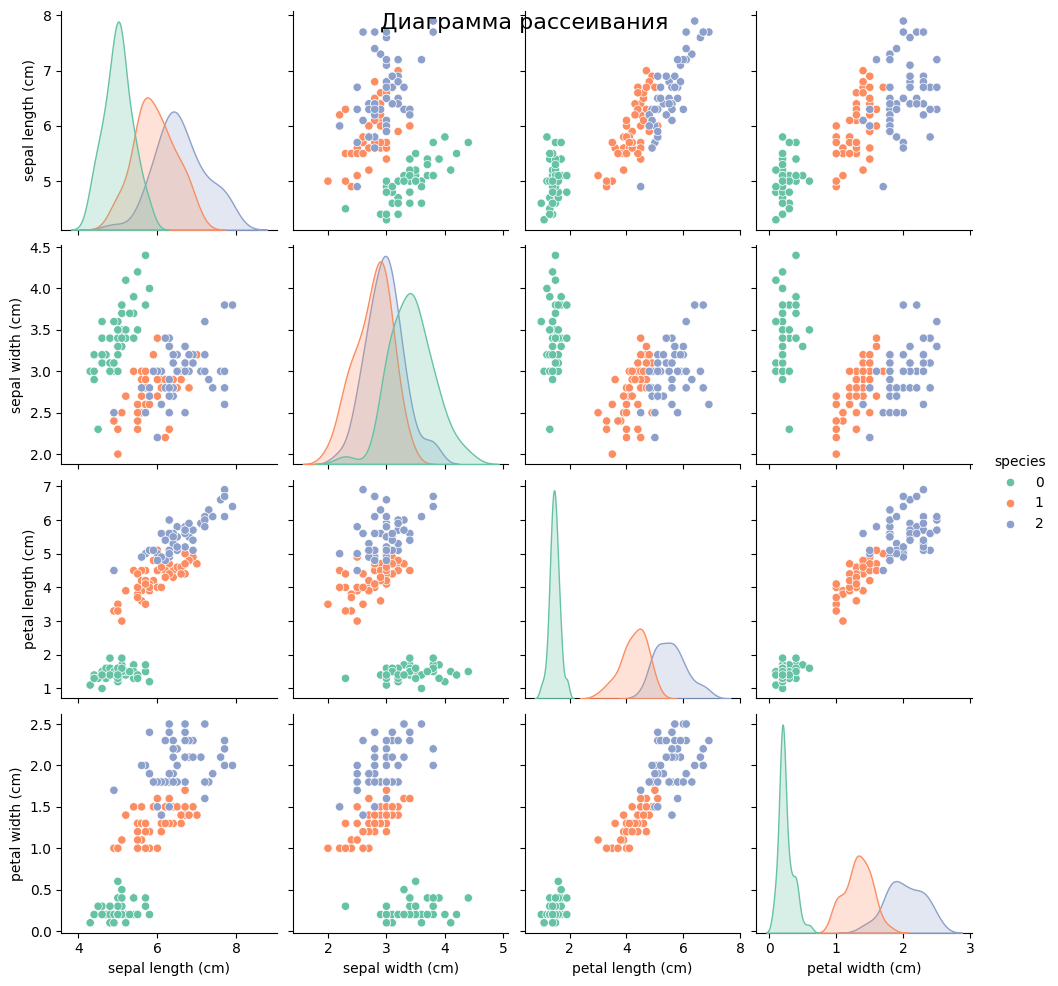

In [21]:
df['species'] = data.target
plt.figure(figsize=(5, 3))
sns.pairplot(df, hue="species", palette="Set2")
plt.suptitle('Диаграмма рассеивания', size=16)
plt.show()

#### Обработка данных

In [18]:
# Нормализация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
# Преобразование меток в one-hot формат
y_train_one_hot = np.eye(3)[y_train]
y_test_one_hot = np.eye(3)[y_test]

# Преобразование данных в тензоры
X_train_tensor = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train_one_hot, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test_one_hot, dtype=tf.float32)

#### Что использовано?
- 1 слой из 128 нейронов
- learning rate (коэфф скорости обучения) = 0.25
- Увеличил количество эпох до 100 (ниже будет график со скоростью обучения)
- была идея добавить дропаут, но не прижилась

In [24]:
# Модель с одним скрытым слоем
class SimpleModel(tf.Module):
    def __init__(self):
        super().__init__()
        # Определяем параметры для скрытых слоев и выходного слоя
        self.W1 = tf.Variable(tf.random.normal([4, 128]))  # Вес для первого скрытого слоя
        self.b1 = tf.Variable(tf.zeros([128]))  # Смещение для второго скрытого слоя

        self.W2 = tf.Variable(tf.random.normal([128, 3]))  # Вес для выходного слоя (3 класса)
        self.b2 = tf.Variable(tf.zeros([3]))  # Смещение для выходного слоя

    def __call__(self, x, training=False): # добавил дропауты
        hidden_layer_1 = tf.nn.relu(tf.matmul(x, self.W1) + self.b1)
        #hidden_layer_1 = tf.nn.dropout(hidden_layer_1, rate=0.2) if training else hidden_layer_1
        
        output_layer = tf.nn.softmax(tf.matmul(hidden_layer_1, self.W2) + self.b2)
        return output_layer
        
# Функция потерь
def compute_loss(logits, labels):
    return tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=labels, logits=logits))
# Функция для вычисления точности
def compute_accuracy(logits, labels):
    predictions = tf.argmax(logits, axis=1)
    correct_predictions = tf.equal(predictions, tf.argmax(labels, axis=1))
    return tf.reduce_mean(tf.cast(correct_predictions, tf.float32))
    
# Оптимизатор Adagard
optimizer = tf.optimizers.Adagrad(learning_rate=0.25)# добавил дк
# Пример тренировочной функции
def train_step(model, images, labels):
    with tf.GradientTape() as tape:
        logits = model(images, training=True)  # Прямой проход через модель
        loss = compute_loss(logits, labels)
        accuracy = compute_accuracy(logits, labels)
    gradients = tape.gradient(loss, model.trainable_variables)  # Вычисление градиентов
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))  # Применение градиентов
    return loss, accuracy
    
# Инициализация модели
model_tensor = SimpleModel()
loss_by_epoch = []

# Обучение модели
for epoch in range(100):  # СДЕЛАЛ 100 эпох
    loss, accuracy = train_step(model_tensor, X_train_tensor, y_train_tensor)
    loss_by_epoch.append(loss)
    print(f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}, Accuracy: {accuracy.numpy():.4f}")
    
# Оценка модели на тестовой выборке
logits_test = model_tensor(X_test_tensor)
test_accuracy = compute_accuracy(logits_test, y_test_tensor)
test_loss = compute_loss(logits_test, y_test_tensor)
print(f"Test Loss: {test_loss.numpy():.4f}, Test Accuracy: {test_accuracy.numpy():.4f}")
model_tensor1 = model_tensor

Epoch 1, Loss: 1.4866, Accuracy: 0.0417
Epoch 2, Loss: 1.4339, Accuracy: 0.1000
Epoch 3, Loss: 1.3890, Accuracy: 0.1500
Epoch 4, Loss: 1.2991, Accuracy: 0.2417
Epoch 5, Loss: 1.1955, Accuracy: 0.3333
Epoch 6, Loss: 1.1118, Accuracy: 0.4417
Epoch 7, Loss: 1.0814, Accuracy: 0.4583
Epoch 8, Loss: 1.0625, Accuracy: 0.4750
Epoch 9, Loss: 1.0337, Accuracy: 0.4917
Epoch 10, Loss: 1.0052, Accuracy: 0.5333
Epoch 11, Loss: 0.9665, Accuracy: 0.5667
Epoch 12, Loss: 0.9286, Accuracy: 0.6167
Epoch 13, Loss: 0.9057, Accuracy: 0.6250
Epoch 14, Loss: 0.8734, Accuracy: 0.6500
Epoch 15, Loss: 0.8563, Accuracy: 0.6833
Epoch 16, Loss: 0.8352, Accuracy: 0.7167
Epoch 17, Loss: 0.8120, Accuracy: 0.7250
Epoch 18, Loss: 0.7934, Accuracy: 0.7583
Epoch 19, Loss: 0.7813, Accuracy: 0.7583
Epoch 20, Loss: 0.7643, Accuracy: 0.7917
Epoch 21, Loss: 0.7569, Accuracy: 0.7833
Epoch 22, Loss: 0.7397, Accuracy: 0.8167
Epoch 23, Loss: 0.7426, Accuracy: 0.8000
Epoch 24, Loss: 0.7270, Accuracy: 0.8333
Epoch 25, Loss: 0.7257, A

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
ROC-AUC Score: 1.0000


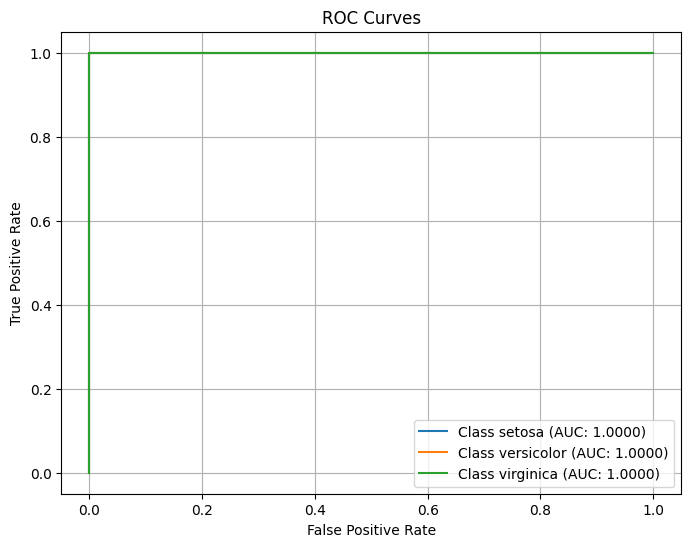

In [6]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

model_tensor = model_tensor1
# Прогнозы модели на тестовой выборке
logits_test = model_tensor(X_test_tensor)
test_predictions = tf.argmax(logits_test, axis=1).numpy()  # Прогнозы классов
test_probabilities = logits_test.numpy()  # Вероятности классов

# Матрица ошибок
conf_matrix = confusion_matrix(y_test, test_predictions)
print("Confusion Matrix:")
print(conf_matrix)

# ROC-AUC метрики
# Поскольку у нас 3 класса, используем подход "one-vs-rest" для многоклассового ROC-AUC
roc_auc = roc_auc_score(y_test_one_hot, test_probabilities, multi_class='ovr')
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Построение ROC-кривых для каждого класса
fpr = {}
tpr = {}
for i in range(3):  # По числу классов
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], test_probabilities[:, i])

# График ROC-кривых
plt.figure(figsize=(8, 6))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {data['target_names'][i]} (AUC: {roc_auc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

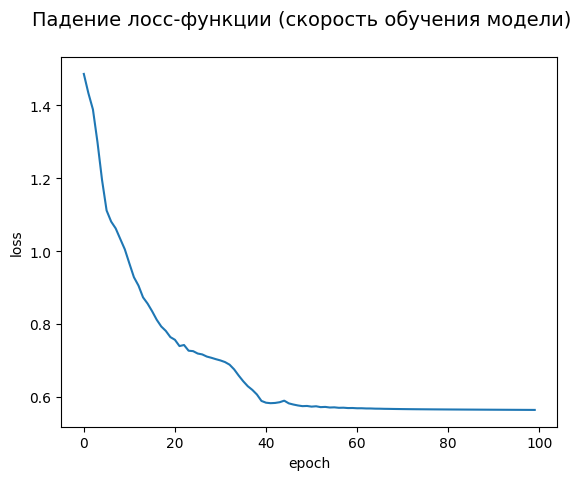

In [25]:
plt.plot(loss_by_epoch)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.suptitle('Падение лосс-функции (скорость обучения модели)', size=14);

Впринципе модель хорошо работает где то после 20 эпохи, а после 60 окончательно сглаживается. Однако для наглядности взял 100 эпох

-------------
Здесь все то же самое, только теперь с помощью Keras

In [14]:
# Разделение данных на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Нормализация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание модели нейронной сети
model_keras = keras.Sequential([
keras.layers.Dense(128, activation='relu', input_shape=(4,)),
#keras.layers.Dropout(0.1),
keras.layers.Dense(3, activation='softmax')
])

# Компиляция модели
model_keras.compile(optimizer = keras.optimizers.Adagrad(learning_rate=0.25),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Обучение модели
history = model_keras.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1)

# Оценка модели на тестовых данных
test_loss, test_accuracy = model_keras.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy}')
print(f'Test loss: {test_loss}')

Epoch 1/100


C:\Dev\Jupyter\dist\pyenv3.12.7-win64\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6088 - loss: 0.7217 - val_accuracy: 0.9167 - val_loss: 0.4405
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8784 - loss: 0.3059 - val_accuracy: 0.9167 - val_loss: 0.3085
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8687 - loss: 0.2618 - val_accuracy: 0.9167 - val_loss: 0.3106
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9492 - loss: 0.1647 - val_accuracy: 0.9167 - val_loss: 0.2302
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9724 - loss: 0.1440 - val_accuracy: 0.9167 - val_loss: 0.2985
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9825 - loss: 0.1180 - val_accuracy: 0.9167 - val_loss: 0.1733
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9736 - loss: 0.0803 - val_accuracy: 0.9167 - val_loss: 0.2850
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9654 - loss: 0.0813 - val_accuracy: 1.0000 - val_loss: 0.1409
Epoc

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
ROC-AUC Score: 1.0000


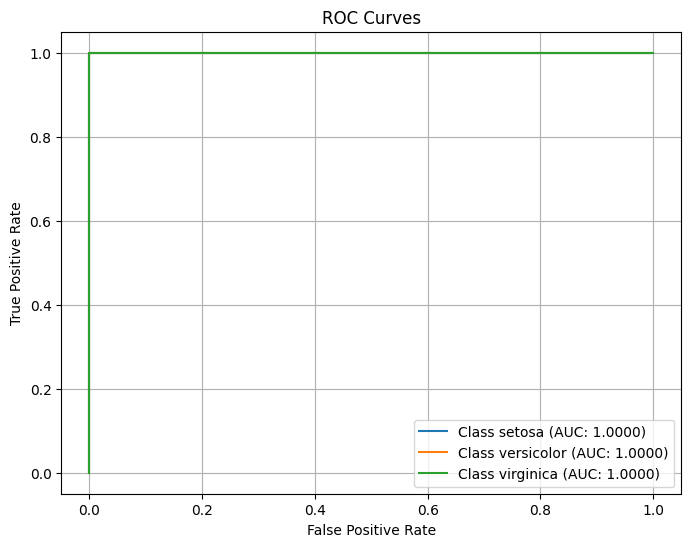

In [114]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Прогнозы модели на тестовой выборке
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test_one_hot, dtype=tf.float32)

logits_test = model_keras(X_test_tensor)
test_predictions = tf.argmax(logits_test, axis=1).numpy()  # Прогнозы классов)
test_probabilities = logits_test.numpy()  # Вероятности классов

# Матрица ошибок
conf_matrix = confusion_matrix(y_test, test_predictions)
print("Confusion Matrix:")
print(conf_matrix)

# ROC-AUC метрики
# Поскольку у нас 3 класса, используем подход "one-vs-rest" для многоклассового ROC-AUC
roc_auc = roc_auc_score(y_test_one_hot, test_probabilities, multi_class='ovr')
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Построение ROC-кривых для каждого класса
fpr = {}
tpr = {}
for i in range(3):  # По числу классов
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], test_probabilities[:, i])

# График ROC-кривых
plt.figure(figsize=(8, 6))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {data['target_names'][i]} (AUC: {roc_auc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

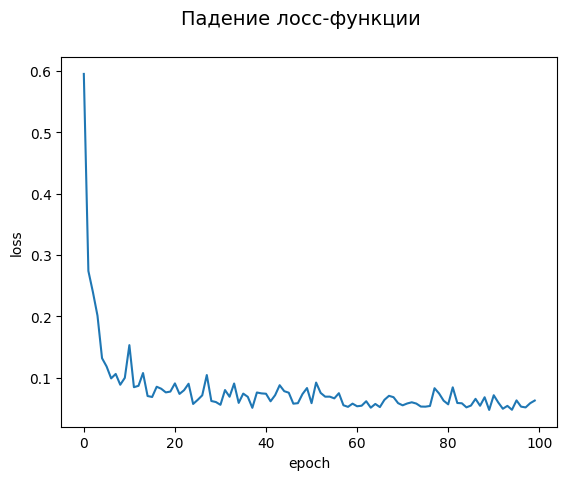

In [16]:
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.suptitle('Падение лосс-функции', size=14);

Ситуация та же, что и с прошлой моделью

### ВТОРАЯ ЛАБА

Просчитать одну итерацию цикла обучения методом обратного распространения
ошибки многослойной однородной НС, состоящей из 3 слоев
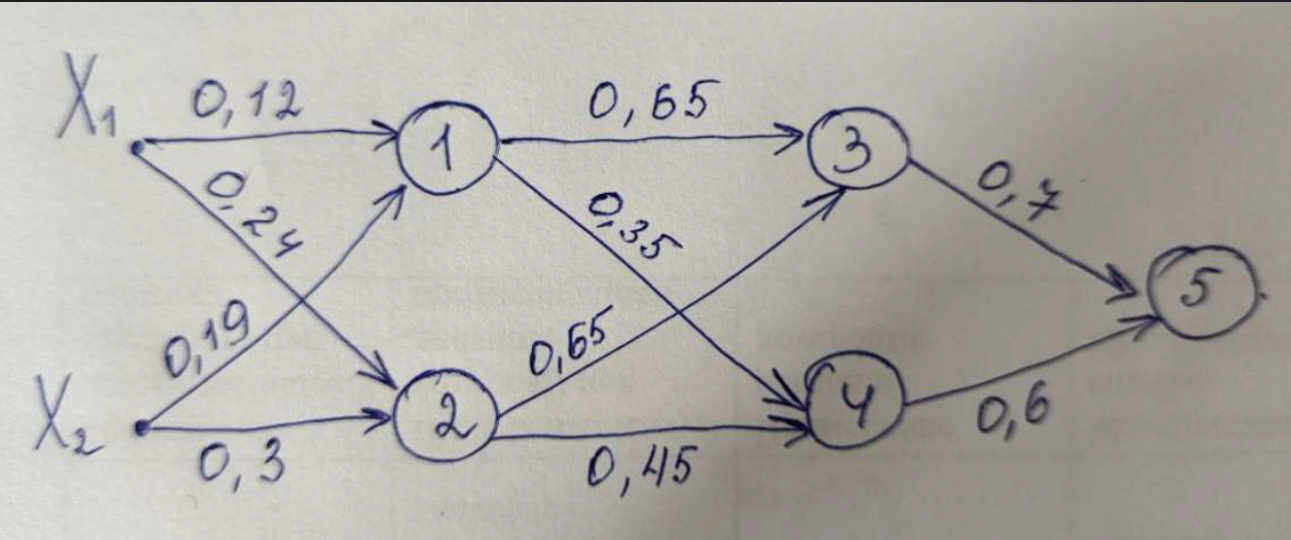
\
Входные данные: $X_1 = 0.7, X_2 = 0.4$
\
Гиперпараметры: $\mu = 0.75$ 
\
Таргет: $z_{target} = 0.5$
\
Веса:
\
Нейрон (1): $\begin{bmatrix} 0.12 \\ 0.19 \end{bmatrix}$, 
\
Нейрон (2): $\begin{bmatrix} 0.24 \\ 0.3 \end{bmatrix}$, 
\
Нейрон (3): $\begin{bmatrix} 0.65 \\ 0.65 \end{bmatrix}$, 
\
Нейрон (4): $\begin{bmatrix} 0.35 \\ 0.45 \end{bmatrix}$, 
\
Нейрон(выходной) (5): $\begin{bmatrix} 0.7 \\ 0.6 \end{bmatrix}$

### Проход вперед (forward):
Считаем веса нейронов:
(1) = $\sigma(0.12*0.7+0.19*0.4) = \frac{1}{1+e^{0.16}} = 0.5399148845555657$ 
\
(2) = $\sigma(0.24*0.7+0.3*0.4) = \frac{1}{1+e^{0.288}} = 0.5715064294675559$ 
\
(3) = $\sigma(0.65*(1)+0.65*(2)) = \frac{1}{1+e^{0.7224238541150291}} = 0.6731405427942779$ 
\
(4) = $\sigma(0.35*(1)+0.45*(2)) = \frac{1}{1+e^{0.4461481028548482}} = 0.6097230215600308$ 
\
(5) = $\sigma(0.7*(3)+0.6*(4)) = \frac{1}{1+e^{0.837032192892013}} = 0.6978397936047815$ 
\
Предсказание модели: $z = 0.6978397936047815$
\
Ошибка: $err = z_{targer} - z_{предсказанное} = 0.5 - 0.6978397936047815 = -0.19783979360478154$ 
### Проход назад (backward):\
$\sigma' = \sigma*(1-\sigma)$
\
$\delta = \sigma'*\text{err} = \sigma*(1-\sigma)*\text{err}$
\
a - входное значение
\
$w_{i новый} = w_i+\mu$ * (a) * $\delta$ 
\
(5):
\
Градиент: $\delta_5 = 0.6978397936047815*(1-0.6978397936047815)*(-0.19783979360478154) = -0.041716383354204786$
\
Первый вес:$w_1 = 0.7 + 0.75 * (3)*\delta_5 = 0.7 + 0.75 * 0.6731405427942779 * (-0.041716383354204786) = 0.6789392582991522$
\
Второй вес:$w_2 = 0.6+0.75*(4)*\delta_5 = 0.6 + 0.76*0.6097230215600308*-0.041716383354204786 = 0.5806690661264654$
\
Новые веса для (5):  $\begin{bmatrix} 0.6789392582991522 \\ 0.5806690661264654 \end{bmatrix}$
\
(4):
\
Градиент: $\delta_4 = 0.6097230215600308 * (1-0.6097230215600308)*(-0.19783979360478154) = -0.04707812713951819$
\
Первый вес: $w_1 = 0.35 + 0.75*(1)*\delta_4 = 0.35+0.75*0.5399148845555657*(-0.04707812713951819) = 0.3309363638152811$
\
Второй вес:$w_2 = 0.45 + 0.75*(2)*\delta_4 = 0.45+0.75*0.5715064294675559*(-0.04707812713951819) = 0.42982091073935574$
\
Новые веса для (4):  $\begin{bmatrix} 0.3309363638152811 \\ 0.42982091073935574 \end{bmatrix}$
\
(3):
\
Градиент: $\delta_3 = 0.6731405427942779 * (1-0.6731405427942779)*(-0.19783979360478154) = -0.043529176795346715$
\
Первый вес:$w_1 = 0.65+0.75*(1)*\delta_3 = 0.65+0.75*0.5399148845555657*(-0.043529176795346715) = 0.6323734621518062$
\
Второй вес:$w_2 = 0.65+0.75*(2)*\delta_3 = 0.65+0.75*0.5715064294675559*(-0.043529176795346715) = 0.6313420966940221$
\
Новые веса для (3):  $\begin{bmatrix} 0.6323734621518062 \\ 0.6313420966940221\end{bmatrix}$
\
(2)
\
Градиент: $\delta_2 = 0.5715064294675559*(1-0.5715064294675559)*(-0.19783979360478154) = -0.048448360011512634$
\
Первый вес:$w_1 = 0.24 + 0.75*X_1*\delta_2 =0.24 + 0.75 * 0.7*(-0.048448360011512634) = 0.21456461099395585$
\
Второй вес:$w_2 = 0.3 + 0.75 * X_2*\delta_2 =  0.3 + 0.75 * 0.4*(-0.048448360011512634)=0.2854654919965462$
\
Новые веса для (2):$\begin{bmatrix} 0.21456461099395585 \\ 0.2854654919965462\end{bmatrix}$
\
(1)
\
Градиент: $\delta_1=0.5399148845555657*(1-0.5399148845555657)*(-0.19783979360478154)=-0.04914475043590663$
\
Первый вес:$w_1 = 0.12+0.75*X_1*\delta_1=0.12 + 0.75*0.7*(-0.04914475043590663)=0.09419900602114901$
\
Второй вес:$w_2 = 0.19+0.75*X_2*\delta_1=0.19+0.75*0.4*(-0.04914475043590663)=0.17525657486922802$
\
Новые веса для (1):$\begin{bmatrix} 0.09419900602114901 \\ 0.17525657486922802\end{bmatrix}$
